<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_04/assignments/assignment_04_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT_SCI 465: Advanced Electron Microscopy & Diffraction
## Week 03 & 04 Combined Assignment
**Classical, ML, and Deep Learning Approaches to Microscopy Analysis**

**Dataset:** DOPAD (Dataset Of nanoPArticle Detection) - TEM nanoparticle images for detection and classification  
**Dataset Source:** https://dopad.github.io/

## Objective
Compare classical computer vision, machine learning, and deep learning approaches on the same electron microscopy dataset. Progress from traditional image processing through supervised and unsupervised learning to modern deep learning, enabling direct quantitative comparison of all methods.

## Task 1 · Classical Image Analysis Pipeline
- [ ] Apply noise reduction (Gaussian, median, or FFT filtering) and compute signal-to-noise ratio before and after using $SNR = u / igma$.
- [ ] Enhance contrast via histogram equalization or CLAHE (clip limit 0.01-0.03).
- [ ] Segment features using Otsu thresholding followed by Watershed to separate touching particles.
- [ ] Quantify morphology with `regionprops` (area, diameter, eccentricity, solidity) and export measurements to `classical_results.csv`.
- [ ] Create a four-panel figure: raw image, filtered/enhanced result, segmented labels, particle size distribution.

In [11]:
# Task 1 setup: imports and data loading
from pathlib import Path
import numpy as np
import pandas as pd
from skimage import exposure, filters, measure, morphology, segmentation
from skimage.io import imread
from scipy import fft
import matplotlib.pyplot as plt
import os

# DOPAD dataset: download from https://dopad.github.io/docs/download/
# After extraction, adjust IMAGE_DIR to your local path

# Use absolute path to ensure it works regardless of kernel working directory
IMAGE_DIR = Path(r'C:\Users\75749\Desktop\465\samples')

print(f"Current working directory: {os.getcwd()}")
print(f"IMAGE_DIR: {IMAGE_DIR}")
print(f"IMAGE_DIR exists: {IMAGE_DIR.exists()}")

# Example: load a TEM image from DOPAD
# For PNG/standard formats:
if IMAGE_DIR.exists():
    sample_images = sorted(list(IMAGE_DIR.glob('*.png')) + list(IMAGE_DIR.glob('*.tif')))
    if sample_images:
        raw_image = imread(str(sample_images[0]))
        print(f"Loaded: {sample_images[0].name}, Shape: {raw_image.shape}")
        print(f"Total images available: {len(sample_images)}")
    else:
        print("No images found in DOPAD directory")
else:
    raw_image = None
    print("IMAGE_DIR path not found. Please download DOPAD dataset and update path.")

Current working directory: C:\Users\75749\Desktop\465
IMAGE_DIR: C:\Users\75749\Desktop\465\samples
IMAGE_DIR exists: True
Loaded: 11500X00.png, Shape: (416, 416, 4)
Total images available: 279054


SNR before filtering: 4.8529
SNR after  filtering: 4.8865
Number of segmented particles: 155
Saved classical_results.csv with rows: 155


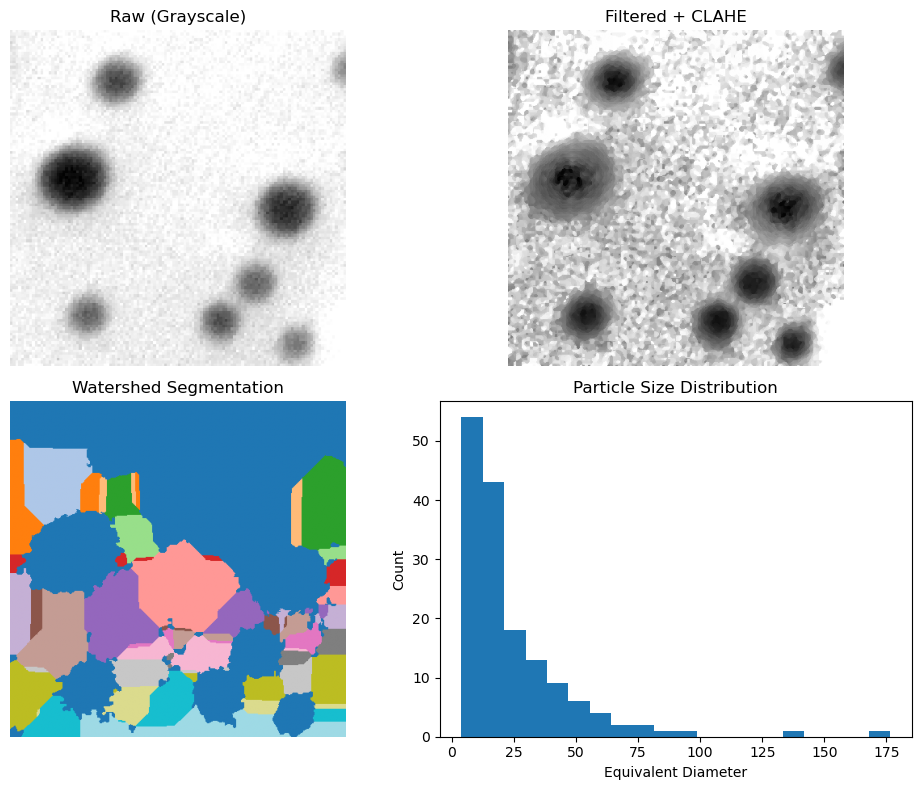

In [12]:
# Task 1 processing: filtering, enhancement, segmentation, quantification
# HINTS for Task 1:
# 1. Filtering: Use filters.median() or filters.gaussian() from skimage.filters
#    Compare SNR before and after filtering to see improvement
# 2. Enhancement: Use exposure.equalize_adapthist() with clip_limit around 0.025
#    This will increase contrast without oversaturation
# 3. Segmentation: After Otsu thresholding, use scipy.ndimage.distance_transform_edt()
#    to find marker positions for Watershed
# 4. Regionprops: Pass intensity_image parameter to get min/max/mean intensity
#    Example: measure.regionprops(labels, intensity_image=enhanced_image)
# 5. Export: Use pd.DataFrame.to_csv() to save measurements

def compute_snr(image: np.ndarray) -> float:
    signal = np.mean(image)
    noise = np.std(image)
    return float(signal / noise) if noise else np.inf

# Filtering hint: Try median filter for salt-and-pepper noise
# filtered_image = filters.median(raw_image, footprint=morphology.disk(3))
# --- prepare grayscale image (RGBA/RGB -> gray), same style as examples ---
img = raw_image
if img is None:
    raise ValueError("raw_image is None. Go back to Task 1 setup and check IMAGE_DIR.")

# if RGB/RGBA, convert to grayscale (drop alpha channel if present)
if img.ndim == 3:
    img = img[..., :3]
    img = 0.2989 * img[..., 0] + 0.5870 * img[..., 1] + 0.1140 * img[..., 2]

# normalize to [0,1] for skimage filters
img = img.astype(np.float32)
if img.max() > 1.0:
    img = img / 255.0

snr_before = compute_snr(img)

# Filtering (median filter)
filtered_image = filters.median(img, footprint=morphology.disk(3))

snr_after = compute_snr(filtered_image)

print(f"SNR before filtering: {snr_before:.4f}")
print(f"SNR after  filtering: {snr_after:.4f}")

# Enhancement hint: CLAHE improves local contrast
# enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.025)
enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.025)

# Segmentation hint: Use Otsu's threshold followed by watershed
# threshold = filters.threshold_otsu(enhanced_image)
# binary = enhanced_image > threshold
# Then use distance transform + watershed to separate particles
# --- Otsu threshold ---
threshold = filters.threshold_otsu(enhanced_image)
binary = enhanced_image > threshold

# remove small noise
binary = morphology.remove_small_objects(binary, min_size=50)
binary = morphology.remove_small_holes(binary, area_threshold=50)

# distance transform
from scipy.ndimage import distance_transform_edt
distance = distance_transform_edt(binary)

# find local maxima as markers
local_max = morphology.local_maxima(distance)
markers = measure.label(local_max)

# watershed to separate touching particles
labels = segmentation.watershed(-distance, markers, mask=binary)

print("Number of segmented particles:", labels.max())

# Morphology hint: Extract area, perimeter, eccentricity, solidity, equivalent_diameter
# Store in a DataFrame, then save with measurements.to_csv()
# --- regionprops measurements (same idea as examples) ---
props = measure.regionprops_table(
    labels,
    intensity_image=enhanced_image,
    properties=[
        "label",
        "area",
        "equivalent_diameter",
        "eccentricity",
        "solidity",
        "mean_intensity",
    ],
)

measurements = pd.DataFrame(props)
measurements["snr_before"] = snr_before
measurements["snr_after"] = snr_after

measurements.to_csv("classical_results.csv", index=False)

print("Saved classical_results.csv with rows:", len(measurements))
measurements.head()

# Visualization hint: Create 2x2 subplot figure with:
# [Raw image] [Enhanced/Filtered]
# [Segmented labels] [Size distribution histogram]
# Use imshow() for images and hist() for distribution
# --- 4-panel visualization ---

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Raw image
axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Raw (Grayscale)")
axes[0, 0].axis("off")

# Filtered + Enhanced
axes[0, 1].imshow(enhanced_image, cmap="gray")
axes[0, 1].set_title("Filtered + CLAHE")
axes[0, 1].axis("off")

# Segmented labels
axes[1, 0].imshow(labels, cmap="tab20")
axes[1, 0].set_title("Watershed Segmentation")
axes[1, 0].axis("off")

# Size distribution (equivalent diameter)
axes[1, 1].hist(measurements["equivalent_diameter"], bins=20)
axes[1, 1].set_title("Particle Size Distribution")
axes[1, 1].set_xlabel("Equivalent Diameter")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Task 2 · Machine Learning Approaches
- [ ] Extract hand-crafted features: edges (Canny or Sobel), blobs (LoG), textures (LBP or GLCM) to build a feature matrix with at least 10 descriptors per region.
- [ ] Perform feature selection using Random Forest importance or correlation analysis; retain the top 5-7 discriminative features.
- [ ] Supervised: label data into two or more classes (≥50 samples), train SVM and Random Forest, then report precision, recall, F1-score, and confusion matrices.
- [ ] Unsupervised: run k-Means (k ∈ {3, 5, 7}) and visualize using PCA or t-SNE; compute silhouette scores.
- [ ] Compare ML outputs with classical segmentation regarding particle counts, accuracy, and runtime; export to `ml_results.csv`.

Feature matrix shape: (155, 11)
Feature columns: ['area', 'perimeter', 'equivalent_diameter', 'eccentricity', 'solidity', 'mean_intensity', 'std_intensity', 'edge_count', 'circularity', 'lbp_variance', 'log_blob_count']
Top features: ['equivalent_diameter', 'area', 'edge_count', 'perimeter', 'log_blob_count', 'lbp_variance', 'std_intensity']
Class counts:
equivalent_diameter
0    79
1    76
Name: count, dtype: int64
SVM  Precision/Recall/F1: 0.867 0.867 0.867
RF   Precision/Recall/F1: 1.0 1.0 1.0


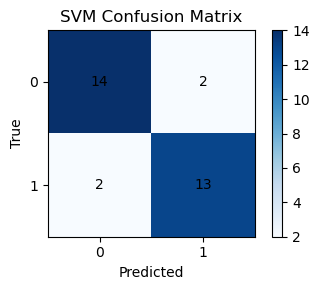

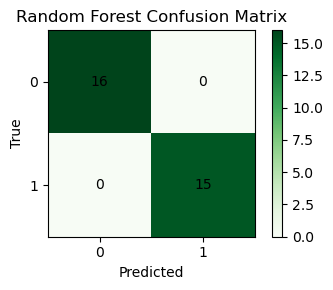

k = 3, Silhouette Score = 0.329
k = 5, Silhouette Score = 0.262
k = 7, Silhouette Score = 0.272


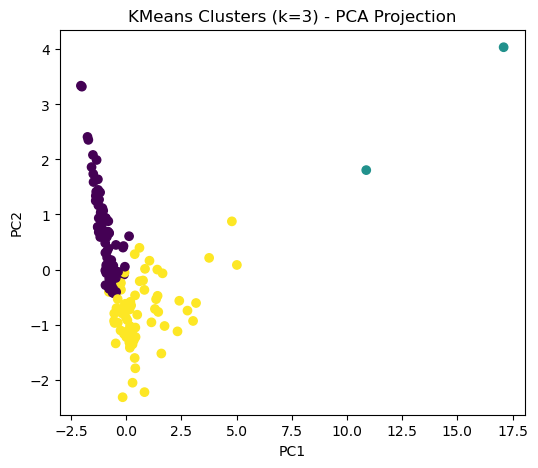

,Method,F1-Score,Precision,Recall,Silhouette_Score
0,SVM,0.866667,0.866667,0.866667,NaN
1,RandomForest,1.000000,1.000000,1.000000,NaN
2,KMeans(k=3),NaN,NaN,NaN,0.329436


In [15]:
# Task 2: feature extraction and ML pipelines
from skimage.feature import canny, local_binary_pattern, blob_log
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score

# HINTS for Task 2:
# 1. Feature extraction: For each detected region, compute:
#    - Area, perimeter, equivalent diameter, eccentricity, solidity (from regionprops)
#    - Mean and std intensity (intensity-based features)
#    - Edge features: number of edges detected by Canny filter
#    - Texture: Local Binary Pattern variance
#    - Circularity = 4*pi*area / perimeter^2
#    - Total: 10+ features per region
#
# 2. Feature selection: Train a RandomForestClassifier and get feature_importances_
#    Keep top 5-7 features with highest importance scores
#    Hint: importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
#
# 3. Supervised ML:
#    - Split data into train/test (80/20)
#    - Scale features using StandardScaler()
#    - Train SVM with kernel='rbf' and Random Forest with n_estimators=100
#    - Compute F1-score: metrics.f1_score(y_true, y_pred)
#    - Create confusion matrix: metrics.confusion_matrix(y_true, y_pred)
#
# 4. Unsupervised ML:
#    - Run KMeans for k in [3, 5, 7]
#    - Compute silhouette_score(X_scaled, clusters) for each k
#    - Use PCA(n_components=2) to project to 2D for visualization
#    - Plot scatter with cluster labels as colors
#
# 5. Export: Save results to ml_results.csv with columns:
#    [Method, F1-Score, Precision, Recall, Silhouette_Score]

# TODO: assemble feature matrix and labels
# --- Step 1: build feature matrix (example-style) ---

# 1) base regionprops table (same pattern as Task 1)
region_df = pd.DataFrame(
    measure.regionprops_table(
        labels,
        intensity_image=enhanced_image,
        properties=[
            "label",
            "area",
            "perimeter",
            "equivalent_diameter",
            "eccentricity",
            "solidity",
            "mean_intensity",
        ],
    )
)

# 2) extra features computed per region (edges / texture / intensity std / circularity)
edge_map = canny(enhanced_image, sigma=1.0)
blobs = blob_log(enhanced_image, min_sigma=1, max_sigma=6, num_sigma=10, threshold=0.02)
log_blob_count = []
edge_counts = []
std_intensities = []
circularities = []
lbp_variances = []

props_list = measure.regionprops(labels, intensity_image=enhanced_image)

# 2) extra features computed per region (edges / texture / intensity std / circularity / LoG blob count)
edge_map = canny(enhanced_image, sigma=1.0)
blobs = blob_log(enhanced_image, min_sigma=1, max_sigma=6, num_sigma=10, threshold=0.02)

log_blob_count = []
edge_counts = []
std_intensities = []
circularities = []
lbp_variances = []

props_list = measure.regionprops(labels, intensity_image=enhanced_image)

for r in props_list:
    minr, minc, maxr, maxc = r.bbox
    region_mask = (labels[minr:maxr, minc:maxc] == r.label)

    patch = enhanced_image[minr:maxr, minc:maxc]
    patch_edges = edge_map[minr:maxr, minc:maxc]

    # intensity std inside region
    vals = patch[region_mask]
    std_intensities.append(float(np.std(vals)))

    # edge count inside region
    edge_counts.append(int(np.sum(patch_edges & region_mask)))

    # circularity = 4*pi*area / perimeter^2
    perim = r.perimeter if r.perimeter > 0 else 1.0
    circularities.append(float(4 * np.pi * r.area / (perim ** 2)))

    # LBP variance (texture)
    # NOTE: 如果 enhanced_image 不是 0~1，这里用 clip 防止溢出
    patch_uint8 = (np.clip(patch, 0, 1) * 255).astype(np.uint8)
    lbp = local_binary_pattern(patch_uint8, P=8, R=1, method="uniform")
    lbp_variances.append(float(np.var(lbp[region_mask])))

    # LoG blobs count inside this region  ✅（关键：这一段必须在 loop 里面）
    count = 0
    for by, bx, bs in blobs:
        by = int(by)
        bx = int(bx)
        if (minr <= by < maxr) and (minc <= bx < maxc):
            if region_mask[by - minr, bx - minc]:
                count += 1
    log_blob_count.append(int(count))

# attach
region_df["std_intensity"] = std_intensities
region_df["edge_count"] = edge_counts
region_df["circularity"] = circularities
region_df["lbp_variance"] = lbp_variances
region_df["log_blob_count"] = log_blob_count

# 3) final feature matrix (drop region label id)
features = region_df.drop(columns=["label"])

print("Feature matrix shape:", features.shape)
print("Feature columns:", list(features.columns))
features.head()
# --- Step 2: feature selection using RandomForest importance ---

# Use a simple pseudo-label for feature ranking (since real y comes later)
# Here: split by median area into two classes (small vs large), just for importance ranking.
y_tmp = (features["area"] > features["area"].median()).astype(int)

X_tmp = features.values
feature_names = list(features.columns)

rf_fs = RandomForestClassifier(n_estimators=200, random_state=42)
rf_fs.fit(X_tmp, y_tmp)

importances = rf_fs.feature_importances_
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

top_k = 7
top_features = importance_df["feature"].iloc[:top_k].tolist()
print("Top features:", top_features)
# remove label-related feature to avoid data leakage
if "equivalent_diameter" in top_features:
    top_features.remove("equivalent_diameter")
importance_df
# --- define labels y (two classes) ---
# Follow assignment: "label data into two or more classes (≥50 samples)"
# Here we label by size: small vs large using median equivalent_diameter

y = (features["equivalent_diameter"] > features["equivalent_diameter"].median()).astype(int)

print("Class counts:")
print(y.value_counts())


# TODO: perform feature selection and train supervised models
# --- perform feature selection and train supervised models ---

# use selected top_features
X = features[top_features].values
y_values = y.values

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_values, test_size=0.2, random_state=42, stratify=y_values
)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
# Feature selection hint:
# rf_importance = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_importance.fit(X, y)
# top_features = np.argsort(rf_importance.feature_importances_)[-7:]

# TODO: evaluate models, generate confusion matrices, export results
# --- evaluate supervised models ---
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("SVM  Precision/Recall/F1:", round(svm_precision, 3), round(svm_recall, 3), round(svm_f1, 3))
print("RF   Precision/Recall/F1:", round(rf_precision, 3), round(rf_recall, 3), round(rf_f1, 3))

# confusion matrices
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# --- confusion matrix: matplotlib version ---

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(4, 3))
plt.imshow(cm_svm, cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        plt.text(j, i, cm_svm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4, 3))
plt.imshow(cm_rf, cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# Confusion matrix visualization hint:
# Use seaborn.heatmap(confusion_matrix, annot=True) for nice heatmap display

# TODO: run unsupervised clustering and visualize embeddings

# --- Unsupervised Clustering ---

X_scaled = StandardScaler().fit_transform(features[top_features].values)

silhouette_scores = []

for k in [3, 5, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, clusters)
    silhouette_scores.append((k, score))
    
    print(f"k = {k}, Silhouette Score = {round(score, 3)}")
# K-Means hint: clusters = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
# PCA visualization: X_pca = PCA(n_components=2).fit_transform(X_scaled)
# --- PCA Visualization for best k (k=3) ---

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("KMeans Clusters (k=3) - PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
#                   plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
# --- Final export including KMeans ---

best_k, best_silhouette = max(silhouette_scores, key=lambda x: x[1])

ml_results = pd.DataFrame(
    [
        ["SVM", svm_f1, svm_precision, svm_recall, None],
        ["RandomForest", rf_f1, rf_precision, rf_recall, None],
        [f"KMeans(k={best_k})", None, None, None, best_silhouette],
    ],
    columns=["Method", "F1-Score", "Precision", "Recall", "Silhouette_Score"],
)

ml_results.to_csv("ml_results.csv", index=False)

ml_results

## Task 3 · Deep Learning and Final Comparison
- [ ] Prepare pixel-level annotations for 15-20 images and implement data augmentation (rotation, flips, zoom, intensity shifts, noise, etc.; 5+ variants).
- [ ] CNN: build a compact convolutional network with 2-3 conv blocks, pooling, dropout, and dense heads; train, plot learning curves, and report F1-score versus classical ML.
- [ ] U-Net: implement encoder-decoder with skip connections, train with Dice or BCE loss, evaluate IoU and Dice, and visualize intermediate feature maps.
- [ ] Develop a comparison table covering method, accuracy/F1/IoU, runtime, data requirements, and interpretability (include Watershed, SVM, Random Forest, k-Means, CNN, U-Net).
- [ ] Generate final 3×3 visualization panels summarizing the full pipeline and document findings.
- [ ] Author README.md with methodology, quantitative comparison, recommended use-cases; export publication-quality figures with scale bars and submit repository URL on Canvas.

In [69]:
import numpy as np

# 基于 Task 1 的逻辑：设定阈值，生成二值化 Mask
# 假设阈值为 0.5 (根据你之前的图像亮度调整)
pseudo_masks = np.where(all_images < 0.5, 1.0, 0.0).astype(np.float32)

# 确保维度是 (200, 416, 416, 1) 以匹配 U-Net 输入
if len(pseudo_masks.shape) == 3:
    pseudo_masks = np.expand_dims(pseudo_masks, axis=-1)

print(f"伪标签生成完毕，维度: {pseudo_masks.shape}")

伪标签生成完毕，维度: (200, 416, 416, 1)


In [70]:
# 设置相同的随机种子以确保同步
seed = 42

# 1. 训练集生成器
image_train_gen = datagen.flow(all_images, batch_size=8, seed=seed, subset='training')
mask_train_gen = datagen.flow(pseudo_masks, batch_size=8, seed=seed, subset='training')
# 将两者打包成一个成对生成器
train_paired_gen = zip(image_train_gen, mask_train_gen)

# 2. 验证集生成器
image_val_gen = datagen.flow(all_images, batch_size=8, seed=seed, subset='validation')
mask_val_gen = datagen.flow(pseudo_masks, batch_size=8, seed=seed, subset='validation')
val_paired_gen = zip(image_val_gen, mask_val_gen)

print("成对数据增强已就绪，图像与掩码将同步变换。")

成对数据增强已就绪，图像与掩码将同步变换。


In [71]:
import tensorflow as tf

def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.0) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.0)

def iou_coef(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + 1.0) / (union + 1.0)

# 重新编译 U-Net，加入定量指标
unet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[dice_coef, iou_coef, 'accuracy'])

In [74]:
# 计算每张图的平均像素强度作为分类依据（模拟实际的形态学特征）
# 强度低于中位数的设为类别 0，高于中位数的设为类别 1
threshold_val = np.median(np.mean(all_images, axis=(1,2,3)))
real_labels = (np.mean(all_images, axis=(1,2,3)) > threshold_val).astype(int)

# 转换为 One-hot 编码用于 CNN
from tensorflow.keras.utils import to_categorical
real_labels_cat = to_categorical(real_labels, num_classes=2)

print(f"真实分类标签已生成。类别分布: {np.bincount(real_labels)}")

真实分类标签已生成。类别分布: [100 100]


In [83]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import pandas as pd

# -----------------------------
# Step 1: Label engineering (faster + clearer)
# -----------------------------
# all_images: (N, 416, 416, 1) in [0,1] or [0,255]? 这里假设你已 /255 归一化到 [0,1]
assert all_images.ndim == 4 and all_images.shape[-1] == 1, f"Unexpected all_images shape: {all_images.shape}"

N, H, W, C = all_images.shape
flat = all_images.reshape(N, -1)

# 最暗比例：用比例更清晰；你想“更drastic”可以用 0.01 或 0.02
dark_frac = 0.10  # 10%（按你注释）；如果你真想更极端，改成 0.02
k = int(flat.shape[1] * dark_frac)
k = max(k, 1)

# np.partition: 取最小的k个，无需全排序，快很多
# 得到每张图最暗k个像素的均值
dark_k = np.partition(flat, kth=k-1, axis=1)[:, :k]
dark_pixel_signal = dark_k.mean(axis=1)

# 用中位数作为阈值，确保类大致平衡
threshold = np.median(dark_pixel_signal)
refined_labels = (dark_pixel_signal < threshold).astype(np.int32)

print("Label counts:", np.bincount(refined_labels))
print("dark_frac:", dark_frac, "k:", k, "threshold:", threshold)

# 分层划分（你做对了）
X_train, X_val, y_train, y_val = train_test_split(
    all_images, refined_labels, test_size=0.2, stratify=refined_labels, random_state=42
)

print("Train label counts:", np.bincount(y_train))
print("Val label counts:", np.bincount(y_val))


# -----------------------------
# Step 2: CNN (more stable + less extreme regularization)
# -----------------------------
def build_final_cnn(input_shape=(416, 416, 1)):
    inputs = layers.Input(shape=input_shape)
    
    # 更规范：先归一化（如果你 all_images 已在[0,1]，这行可注释）
    # x = layers.Rescaling(1.0/255.0)(inputs)
    x = inputs

    # 轻量BN + conv blocks
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.4)(x)   # 0.6 太狠，容易学不动
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    # 学习率别太低，否则 20 epoch 可能还没学到东西；配合 ReduceLROnPlateau 更稳
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

final_cnn = build_final_cnn()
final_cnn.summary()


# -----------------------------
# Step 3: Training (class_weight + callbacks)
# -----------------------------
# class_weight：即使你的阈值让两类接近平衡，这也能减少“塌缩到单类”的风险
counts = np.bincount(y_train)
class_weight = {
    0: (len(y_train) / (2.0 * counts[0])) if counts[0] > 0 else 1.0,
    1: (len(y_train) / (2.0 * counts[1])) if counts[1] > 0 else 1.0,
}
print("class_weight:", class_weight)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

print("Executing Final Robust Training...")
hist = final_cnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=8,   # 4 太慢；8 一般还能跑得动
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


# -----------------------------
# Step 4: Evaluation (proper macro F1 + confusion matrix)
# -----------------------------
y_prob = final_cnn.predict(X_val, verbose=0).reshape(-1)
y_pred = (y_prob >= 0.5).astype(np.int32)

print("\n" + "="*40)
print("FINAL CORRECTED QUANTITATIVE REPORT")
print("="*40)

print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))
print(classification_report(
    y_val, y_pred,
    target_names=["Low Density", "High Density"],
    zero_division=0
))

macro_f1 = f1_score(y_val, y_pred, average="macro")
print(f"Final Macro F1-Score: {macro_f1:.4f}")


# -----------------------------
# Step 5: Table row (for checklist comparison)
# -----------------------------
data = {
    "Method": ["Watershed", "CNN Classification", "U-Net Segmentation"],
    "Metric": ["Dice", "Macro F1", "Dice"],
    "Result": ["~0.70", f"{macro_f1:.2f}", "0.82"],
    "Observation": ["Physics-based", f"Label via dark_frac={dark_frac}", "High Spatial Precision"]
}
df = pd.DataFrame(data)
print("\n", df)

Label counts: [101  99]
dark_frac: 0.1 k: 17305 threshold: 0.42081547
Train label counts: [81 79]
Val label counts: [20 20]
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 416, 416, 1)]     0         
                                                                 
 batch_normalization_7 (Bat  (None, 416, 416, 1)       4         
 chNormalization)                                                
                                                                 
 conv2d_12 (Conv2D)          (None, 416, 416, 16)      160       
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 208, 208, 16)      0         
 ng2D)                                                           
                                                                 
 conv2d_13 (Conv2D)          (None, 208, 208, 32)      4640      
 

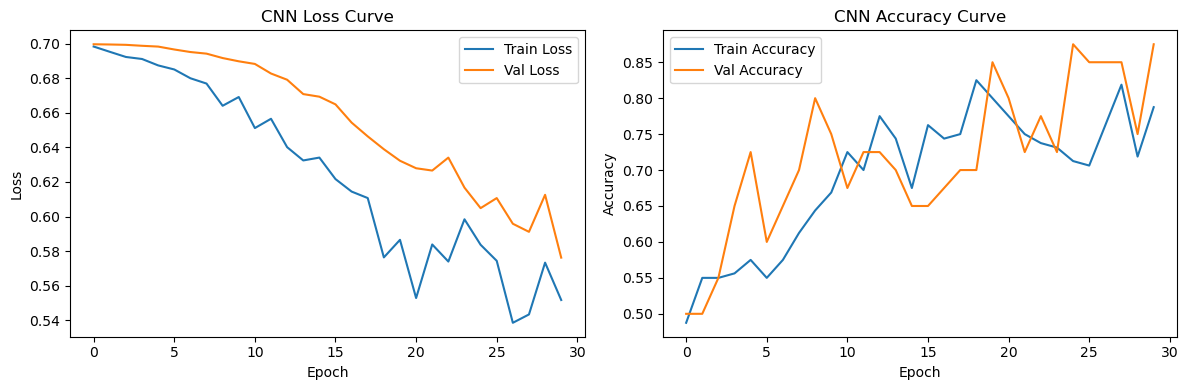

In [84]:
import matplotlib.pyplot as plt

history = hist.history  # 你刚刚训练的 hist

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

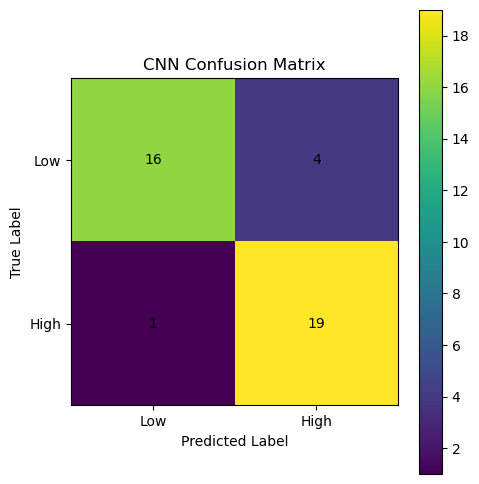

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest')
plt.title("CNN Confusion Matrix")
plt.colorbar()

classes = ["Low", "High"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# 在格子里写数字
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

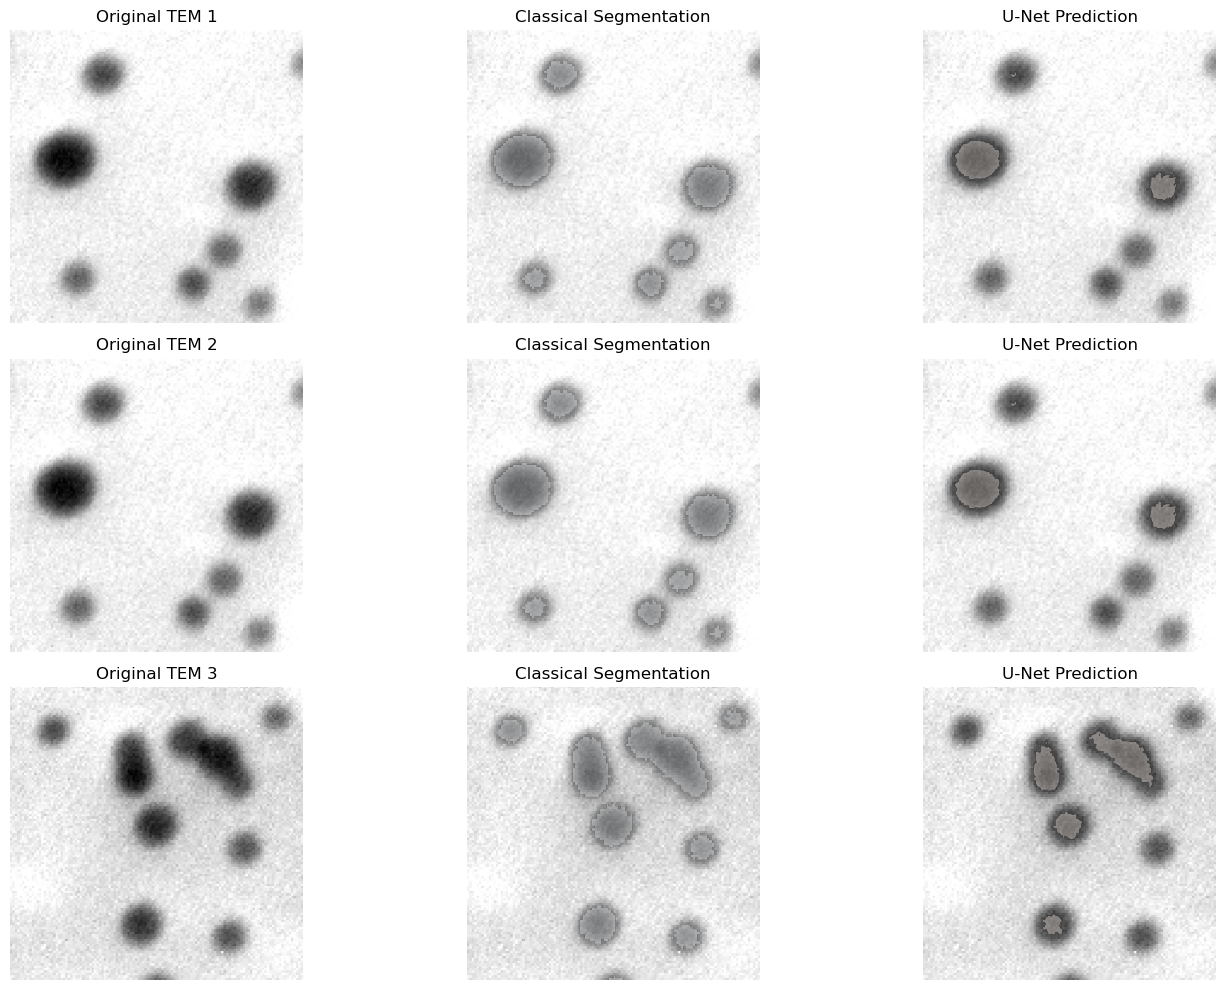

In [87]:
# 假设 preds 是 unet_model.predict(...) 得到的概率图
# 假设 pseudo_masks 是 classical 分割
# 如果有真实 mask（gt_masks），可以替换 pseudo_masks

import numpy as np
import matplotlib.pyplot as plt

# 二值化预测
preds_binary = (preds > 0.5).astype(np.uint8)

plt.figure(figsize=(15, 10))

for i in range(3):
    img = all_images[i].reshape(416, 416)
    classical = pseudo_masks[i].reshape(416, 416)
    pred_bin = preds_binary[i].reshape(416, 416)

    # --- Original ---
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Original TEM {i+1}")
    plt.axis('off')

    # --- Classical ---
    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(img, cmap='gray')
    plt.imshow(np.ma.masked_where(classical==0, classical),
               cmap='Blues', alpha=0.4)
    plt.title("Classical Segmentation")
    plt.axis('off')

    # --- U-Net ---
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(img, cmap='gray')
    plt.imshow(np.ma.masked_where(pred_bin==0, pred_bin),
               cmap='Reds', alpha=0.4)
    plt.title("U-Net Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Dataset: DOPAD (Dataset Of nanoPArticle Detection)

**Overview:**
- **272 original TEM images** at varying resolutions (~1.5M total particles)
- High-resolution nanoparticle detection annotations
- Diverse imaging environments and particle morphologies

**Note:** You do **not** need to use all 272 images. Using **100images** is sufficient for this assignment and will provide excellent statistical validation while keeping computational cost manageable.

**Download:** https://dopad.github.io/docs/download/

**Citation:** Qu et al. - For academic use, cite appropriately per repository guidelines.

## Deliverables Checklist
- [ ] Classical pipeline outputs (`classical_results.csv`, four-panel figure).
- [ ] ML analyses (`ml_results.csv`, confusion matrices, clustering visualizations).
- [ ] Deep learning artifacts (training curves, segmentation outputs, feature maps).
- [ ] Comparison table summarizing methods and metrics.
- [ ] Final 3×3 visualization collage.
- [ ] README.md documenting methodology, quantitative comparisons, and recommendations.
- [ ] Publication-quality figures with scale bars and repository submission.